# 01 — Data Understanding

This notebook profiles the supplied Aeolus Renewables SCADA dataset. It performs structural and diagnostic checks only: no modeling, feature engineering, imputation, row removal, or leakage correction is performed.

## 1. Load & Structural Profile

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
sns.set_theme(style="whitegrid")

project_root = Path.cwd()
if not (project_root / "data" / "raw").exists():
    project_root = project_root.parent
data_path = project_root / "data" / "raw" / "wind_turbine_detection.csv"
if not data_path.is_file():
    raise FileNotFoundError(f"Source dataset not found: {data_path}")

df = pd.read_csv(data_path)
print(f"Loaded source: {data_path.relative_to(project_root)}")

Loaded source: data/raw/wind_turbine_detection.csv


In [2]:
memory_bytes = int(df.memory_usage(index=True, deep=True).sum())
memory_mib = memory_bytes / 1024**2
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
print(f"In-memory footprint: {memory_bytes:,} bytes ({memory_mib:.2f} MiB)")
display(pd.DataFrame({"dtype": df.dtypes.astype(str)}))
display(df.head())

Rows: 131,760
Columns: 35
In-memory footprint: 50,104,752 bytes (47.78 MiB)


,dtype
timestamp,object
turbine_id,object
rated_power_kW,int64
wind_speed_mps,float64
wind_direction_deg,float64
turbulence_intensity,float64
air_density_kgm3,float64
ambient_temp_C,float64
humidity_pct,float64
power_output_kW,float64


,timestamp,turbine_id,rated_power_kW,wind_speed_mps,wind_direction_deg,turbulence_intensity,air_density_kgm3,ambient_temp_C,humidity_pct,power_output_kW,rotor_speed_rpm,generator_speed_rpm,blade_pitch_angle_deg,yaw_misalignment_deg,gearbox_oil_temp_C,gearbox_bearing_temp_C,generator_bearing_temp_C,generator_winding_temp_C,main_bearing_temp_C,nacelle_temp_C,drivetrain_vibration_rms_mmps,tower_vibration_mmps,vib_fft_bearing_bpfo,vib_fft_bearing_bpfi,vib_fft_gearmesh,vib_fft_sideband,oil_particle_count,oil_pressure_bar,operating_hours_total,cumulative_energy_MWh,load_cycles,hours_since_last_maintenance,prior_fault_count,component_age_days,failure
0,1/1/2024 0:00,T001,1500,2.335,151.993,0.149,1.205,21.820,68.717,0.000,0.000,14.414,87.761,-5.455,53.728,56.728,57.637,61.546,48.728,29.820,1.518,0.974,0.455,0.391,0.455,0.399,55.756,6.032,"19,319.612","9,587.146",0.000,769.284,0,"1,360.703",0
1,1/1/2024 0:10,T001,1500,9.166,152.957,0.153,1.200,22.893,74.002,486.762,12.554,"1,134.433",-0.159,0.489,64.105,67.798,66.841,85.072,58.544,33.649,1.480,0.992,0.455,0.391,0.455,0.399,55.756,5.776,"19,319.778","9,587.227",1.528,769.450,0,"1,360.710",0
2,1/1/2024 0:20,T001,1500,9.034,158.402,0.201,1.219,22.899,59.616,454.109,12.579,"1,143.435",1.061,4.220,63.868,66.635,66.093,82.383,58.365,32.667,1.753,1.074,0.455,0.391,0.455,0.399,55.756,5.994,"19,319.945","9,587.302",3.539,769.617,0,"1,360.717",0
3,1/1/2024 0:30,T001,1500,13.284,159.023,0.159,1.181,22.727,64.676,"1,446.811",16.941,"1,526.358",5.718,1.584,83.654,89.761,85.749,128.484,77.257,36.349,1.924,1.379,0.455,0.391,0.455,0.399,55.756,5.541,"19,320.112","9,587.544",5.126,769.784,0,"1,360.724",0
4,1/1/2024 0:40,T001,1500,2.239,159.842,0.189,1.173,23.742,65.423,0.000,0.194,27.405,88.452,3.400,54.573,57.150,56.817,60.963,51.506,32.234,1.497,0.936,0.455,0.391,0.455,0.399,55.756,6.018,"19,320.112","9,587.544",5.126,769.950,0,"1,360.731",0


In [3]:
parsed_timestamp = pd.to_datetime(df["timestamp"], errors="coerce")
timestamp_parse_failures = int(parsed_timestamp.isna().sum())
print(f"Timestamp parse failures: {timestamp_parse_failures:,}")
print(f"Start timestamp: {parsed_timestamp.min()}")
print(f"End timestamp: {parsed_timestamp.max()}")
print(f"Elapsed calendar time: {parsed_timestamp.max() - parsed_timestamp.min()}")

Timestamp parse failures: 0
Start timestamp: 2024-01-01 00:00:00
End timestamp: 2024-03-01 23:50:00
Elapsed calendar time: 60 days 23:50:00


### Per-turbine cadence audit

A turbine is marked contiguous only when its original rows are chronological, its timestamps are unique, and every sorted timestamp interval is exactly 10 minutes. `Missing 10-minute slots` counts implied slots only for intervals longer than 10 minutes.

In [4]:
working_time = df[["turbine_id"]].copy()
working_time["timestamp"] = parsed_timestamp
ten_minutes = np.timedelta64(10, "m")
zero_timedelta = np.timedelta64(0, "ns")
cadence_rows = []
for turbine_id, group in working_time.groupby("turbine_id", sort=True):
    original_times = group["timestamp"]
    out_of_order = int((original_times.diff() < zero_timedelta).sum())
    duplicate_timestamps = int(original_times.duplicated().sum())
    sorted_unique = original_times.dropna().drop_duplicates().sort_values()
    intervals = sorted_unique.diff().dropna()
    gap_intervals = intervals[intervals > ten_minutes]
    irregular_short = intervals[(intervals > zero_timedelta) & (intervals < ten_minutes)]
    missing_slots = int(((gap_intervals / ten_minutes) - 1).apply(np.floor).sum())
    contiguous = bool(
        timestamp_parse_failures == 0
        and out_of_order == 0
        and duplicate_timestamps == 0
        and len(irregular_short) == 0
        and len(gap_intervals) == 0
    )
    cadence_rows.append({
        "turbine_id": turbine_id,
        "records": len(group),
        "first_timestamp": original_times.min(),
        "last_timestamp": original_times.max(),
        "duplicate_timestamps": duplicate_timestamps,
        "out_of_order_transitions": out_of_order,
        "gap_intervals_gt_10m": len(gap_intervals),
        "irregular_intervals_lt_10m": len(irregular_short),
        "missing_10m_slots": missing_slots,
        "contiguous_10m_cadence": contiguous,
    })
cadence_audit = pd.DataFrame(cadence_rows)
print(f"Distinct turbine IDs: {df['turbine_id'].nunique(dropna=True)}")
print("Turbine IDs:", sorted(df["turbine_id"].dropna().unique().tolist()))
display(cadence_audit)

Distinct turbine IDs: 15
Turbine IDs: ['T001', 'T002', 'T003', 'T004', 'T005', 'T006', 'T007', 'T008', 'T009', 'T010', 'T011', 'T012', 'T013', 'T014', 'T015']


,turbine_id,records,first_timestamp,last_timestamp,duplicate_timestamps,out_of_order_transitions,gap_intervals_gt_10m,irregular_intervals_lt_10m,missing_10m_slots,contiguous_10m_cadence
0,T001,8784,2024-01-01,2024-03-01 23:50:00,0,0,0,0,0,True
1,T002,8784,2024-01-01,2024-03-01 23:50:00,0,0,0,0,0,True
2,T003,8784,2024-01-01,2024-03-01 23:50:00,0,0,0,0,0,True
3,T004,8784,2024-01-01,2024-03-01 23:50:00,0,0,0,0,0,True
4,T005,8784,2024-01-01,2024-03-01 23:50:00,0,0,0,0,0,True
5,T006,8784,2024-01-01,2024-03-01 23:50:00,0,0,0,0,0,True
6,T007,8784,2024-01-01,2024-03-01 23:50:00,0,0,0,0,0,True
7,T008,8784,2024-01-01,2024-03-01 23:50:00,0,0,0,0,0,True
8,T009,8784,2024-01-01,2024-03-01 23:50:00,0,0,0,0,0,True
9,T010,8784,2024-01-01,2024-03-01 23:50:00,0,0,0,0,0,True


### Data dictionary

Units and descriptions below are interpretations of the supplied field names. They document working semantics; they are not empirical findings about sensor calibration.

In [5]:
metadata = {
    "timestamp": ("datetime", "identifier/time", "SCADA observation timestamp"),
    "turbine_id": ("identifier", "identifier/time", "Unique turbine identifier"),
    "rated_power_kW": ("kW", "turbine specification", "Turbine rated electrical power"),
    "wind_speed_mps": ("m/s", "wind/environment", "Measured wind speed"),
    "wind_direction_deg": ("degrees", "wind/environment", "Measured wind direction"),
    "turbulence_intensity": ("ratio", "wind/environment", "Wind turbulence intensity"),
    "air_density_kgm3": ("kg/m³", "wind/environment", "Ambient air density"),
    "ambient_temp_C": ("°C", "wind/environment", "Ambient air temperature"),
    "humidity_pct": ("%", "wind/environment", "Relative humidity"),
    "power_output_kW": ("kW", "operating state", "Electrical power output"),
    "rotor_speed_rpm": ("rpm", "operating state", "Low-speed rotor rotational speed"),
    "generator_speed_rpm": ("rpm", "operating state", "Generator rotational speed"),
    "blade_pitch_angle_deg": ("degrees", "operating state", "Blade pitch angle"),
    "yaw_misalignment_deg": ("degrees", "operating state", "Yaw misalignment relative to wind"),
    "gearbox_oil_temp_C": ("°C", "drivetrain sensor", "Gearbox lubricant temperature"),
    "gearbox_bearing_temp_C": ("°C", "drivetrain sensor", "Gearbox bearing temperature"),
    "generator_bearing_temp_C": ("°C", "drivetrain sensor", "Generator bearing temperature"),
    "generator_winding_temp_C": ("°C", "drivetrain sensor", "Generator winding temperature"),
    "main_bearing_temp_C": ("°C", "drivetrain sensor", "Main bearing temperature"),
    "nacelle_temp_C": ("°C", "drivetrain sensor", "Temperature inside the nacelle"),
    "drivetrain_vibration_rms_mmps": ("mm/s RMS", "vibration/FFT", "Drivetrain RMS vibration velocity"),
    "tower_vibration_mmps": ("mm/s", "vibration/FFT", "Tower vibration velocity"),
    "vib_fft_bearing_bpfo": ("amplitude", "vibration/FFT", "FFT amplitude at bearing outer-race fault frequency"),
    "vib_fft_bearing_bpfi": ("amplitude", "vibration/FFT", "FFT amplitude at bearing inner-race fault frequency"),
    "vib_fft_gearmesh": ("amplitude", "vibration/FFT", "FFT amplitude at gear-mesh frequency"),
    "vib_fft_sideband": ("amplitude", "vibration/FFT", "FFT sideband amplitude"),
    "oil_particle_count": ("count", "oil condition", "Oil particle contamination count"),
    "oil_pressure_bar": ("bar", "oil condition", "Lubrication oil pressure"),
    "operating_hours_total": ("hours", "maintenance/usage history", "Cumulative turbine operating hours"),
    "cumulative_energy_MWh": ("MWh", "maintenance/usage history", "Cumulative energy production"),
    "load_cycles": ("cycles", "maintenance/usage history", "Accumulated load cycles"),
    "hours_since_last_maintenance": ("hours", "maintenance/usage history", "Elapsed hours since recorded maintenance"),
    "prior_fault_count": ("count", "maintenance/usage history", "Recorded count of prior faults"),
    "component_age_days": ("days", "maintenance/usage history", "Component age"),
    "failure": ("binary label", "target", "Drivetrain condition label: 0 normal, 1 fault"),
}
assert set(metadata) == set(df.columns), "Data dictionary does not match source columns."
data_dictionary = pd.DataFrame([
    {"column": column, "dtype_on_load": str(df[column].dtype), "unit": metadata[column][0],
     "group": metadata[column][1], "description": metadata[column][2]}
    for column in df.columns
])
display(data_dictionary)

,column,dtype_on_load,unit,group,description
0,timestamp,object,datetime,identifier/time,SCADA observation timestamp
1,turbine_id,object,identifier,identifier/time,Unique turbine identifier
2,rated_power_kW,int64,kW,turbine specification,Turbine rated electrical power
3,wind_speed_mps,float64,m/s,wind/environment,Measured wind speed
4,wind_direction_deg,float64,degrees,wind/environment,Measured wind direction
5,turbulence_intensity,float64,ratio,wind/environment,Wind turbulence intensity
6,air_density_kgm3,float64,kg/m³,wind/environment,Ambient air density
7,ambient_temp_C,float64,°C,wind/environment,Ambient air temperature
8,humidity_pct,float64,%,wind/environment,Relative humidity
9,power_output_kW,float64,kW,operating state,Electrical power output


## 2. Data Quality Checks

In [6]:
missing_by_column = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean().mul(100),
}).sort_values(["missing_count", "missing_pct"], ascending=False)
display(missing_by_column)

missing_by_turbine = (
    df.isna().groupby(df["turbine_id"]).agg(["sum", "mean"])
)
missing_turbine_summary = pd.DataFrame({
    "missing_cells": df.isna().groupby(df["turbine_id"]).sum().sum(axis=1),
    "rows_with_any_missing": df.isna().any(axis=1).groupby(df["turbine_id"]).sum(),
    "rows_with_any_missing_pct": df.isna().any(axis=1).groupby(df["turbine_id"]).mean().mul(100),
})
display(missing_turbine_summary)

missing_by_day = pd.DataFrame({
    "missing_cells": df.isna().sum(axis=1).groupby(parsed_timestamp.dt.date).sum(),
    "rows_with_any_missing": df.isna().any(axis=1).groupby(parsed_timestamp.dt.date).sum(),
})
missing_by_day = missing_by_day[missing_by_day["missing_cells"] > 0]
print(f"Calendar days with at least one missing cell: {len(missing_by_day):,}")
display(missing_by_day)

from scipy.stats import chi2_contingency

row_has_missing = df.isna().any(axis=1)
turbine_missing_table = pd.crosstab(df["turbine_id"], row_has_missing)
day_missing_table = pd.crosstab(parsed_timestamp.dt.date, row_has_missing)
_, turbine_missing_p, _, _ = chi2_contingency(turbine_missing_table)
_, day_missing_p, _, _ = chi2_contingency(day_missing_table)
print(f"Missing-row association with turbine (chi-square p-value): {turbine_missing_p:.6g}")
print(f"Missing-row association with calendar date (chi-square p-value): {day_missing_p:.6g}")
print("At alpha=0.05, turbine association detected:", turbine_missing_p < 0.05)
print("At alpha=0.05, calendar-date association detected:", day_missing_p < 0.05)

,missing_count,missing_pct
generator_bearing_temp_C,690,0.524
gearbox_oil_temp_C,645,0.490
oil_pressure_bar,636,0.483
timestamp,0,0.000
turbine_id,0,0.000
rated_power_kW,0,0.000
wind_speed_mps,0,0.000
wind_direction_deg,0,0.000
turbulence_intensity,0,0.000
air_density_kgm3,0,0.000


,missing_cells,rows_with_any_missing,rows_with_any_missing_pct
turbine_id,,,
T001,120,120,1.366
T002,132,132,1.503
T003,127,127,1.446
T004,135,135,1.537
T005,120,120,1.366
T006,119,118,1.343
T007,146,145,1.651
T008,116,115,1.309
T009,127,125,1.423


Calendar days with at least one missing cell: 61


,missing_cells,rows_with_any_missing
timestamp,,
2024-01-01,36,36
2024-01-02,26,26
2024-01-03,32,32
2024-01-04,28,27
2024-01-05,30,30
2024-01-06,42,42
2024-01-07,28,28
2024-01-08,36,36
2024-01-09,24,24


Missing-row association with turbine (chi-square p-value): 0.575562
Missing-row association with calendar date (chi-square p-value): 0.375868
At alpha=0.05, turbine association detected: False
At alpha=0.05, calendar-date association detected: False


In [7]:
full_row_duplicates = int(df.duplicated().sum())
key_duplicates = int(df.duplicated(subset=["timestamp", "turbine_id"]).sum())
print(f"Duplicate full rows beyond first occurrence: {full_row_duplicates:,}")
print(f"Duplicate timestamp+turbine_id keys beyond first occurrence: {key_duplicates:,}")

Duplicate full rows beyond first occurrence: 0
Duplicate timestamp+turbine_id keys beyond first occurrence: 0


### Physical-range screening

These are conservative screening assumptions, not manufacturer limits: temperatures `[-40, 180] °C`, blade pitch `[-5, 95]°`, yaw misalignment `[-180, 180]°`, humidity `[0, 100]%`, and non-negative wind speed, rotor speed, and power. A flagged value requires domain review; it is not automatically an error.

In [8]:
temperature_columns = [column for column in df.columns if column.endswith("_temp_C")]
screening_rules = {
    "negative_power_output_kW": df["power_output_kW"] < 0,
    "negative_rotor_speed_rpm": df["rotor_speed_rpm"] < 0,
    "negative_wind_speed_mps": df["wind_speed_mps"] < 0,
    "temperature_outside_-40_to_180_C": ~df[temperature_columns].apply(lambda s: s.between(-40, 180) | s.isna()).all(axis=1),
    "blade_pitch_outside_-5_to_95_deg": ~df["blade_pitch_angle_deg"].between(-5, 95),
    "yaw_misalignment_outside_-180_to_180_deg": ~df["yaw_misalignment_deg"].between(-180, 180),
    "humidity_outside_0_to_100_pct": ~df["humidity_pct"].between(0, 100),
}
physical_screen = pd.DataFrame([
    {"screen": name, "flagged_rows": int(mask.sum()), "flagged_pct": mask.mean() * 100}
    for name, mask in screening_rules.items()
])
display(physical_screen)

,screen,flagged_rows,flagged_pct
0,negative_power_output_kW,0,0.000
1,negative_rotor_speed_rpm,0,0.000
2,negative_wind_speed_mps,0,0.000
3,temperature_outside_-40_to_180_C,0,0.000
4,blade_pitch_outside_-5_to_95_deg,0,0.000
5,yaw_misalignment_outside_-180_to_180_deg,0,0.000
6,humidity_outside_0_to_100_pct,0,0.000


### Below-cut-in operating sanity check

Because cut-in speed is turbine-specific and not supplied, results are shown for both 3 and 4 m/s. Working near-zero tolerances are `power_output_kW <= 1`, `rotor_speed_rpm <= 0.1`, and `generator_speed_rpm <= 10`; exceedances are review flags, not confirmed anomalies.

In [9]:
cutin_rows = []
for cutin_mps in [3.0, 4.0]:
    low_wind = df["wind_speed_mps"] < cutin_mps
    cutin_rows.append({
        "cut_in_screen_mps": cutin_mps,
        "rows_below_cut_in": int(low_wind.sum()),
        "power_above_1_kW": int((low_wind & (df["power_output_kW"] > 1)).sum()),
        "rotor_above_0.1_rpm": int((low_wind & (df["rotor_speed_rpm"] > 0.1)).sum()),
        "generator_above_10_rpm": int((low_wind & (df["generator_speed_rpm"] > 10)).sum()),
    })
display(pd.DataFrame(cutin_rows))

,cut_in_screen_mps,rows_below_cut_in,power_above_1_kW,rotor_above_0.1_rpm,generator_above_10_rpm
0,3.000,14875,0,3805,4551
1,4.000,25266,5216,14190,14937


In [10]:
predictor_columns = [column for column in df.columns if column not in ["timestamp", "turbine_id", "failure"]]
variance_profile = pd.DataFrame([
    {
        "column": column,
        "unique_values": df[column].nunique(dropna=True),
        "most_common_value_share_pct": (df[column].value_counts(normalize=True, dropna=True).iloc[0] * 100),
    }
    for column in predictor_columns
])
variance_profile["constant"] = variance_profile["unique_values"] <= 1
variance_profile["near_zero_variance_99pct_rule"] = variance_profile["most_common_value_share_pct"] >= 99
print("Constant predictors:", variance_profile.loc[variance_profile["constant"], "column"].tolist())
print("Near-zero-variance predictors under 99% modal-share rule:",
      variance_profile.loc[variance_profile["near_zero_variance_99pct_rule"], "column"].tolist())
display(variance_profile.sort_values("most_common_value_share_pct", ascending=False))

Constant predictors: []
Near-zero-variance predictors under 99% modal-share rule: []


,column,unique_values,most_common_value_share_pct,constant,near_zero_variance_99pct_rule
30,prior_fault_count,187,63.186,False,False
0,rated_power_kW,5,40.000,False,False
7,power_output_kW,91804,18.361,False,False
8,rotor_speed_rpm,12621,5.617,False,False
9,generator_speed_rpm,117932,3.844,False,False
3,turbulence_intensity,293,1.689,False,False
23,vib_fft_sideband,234,1.421,False,False
21,vib_fft_bearing_bpfi,271,1.421,False,False
20,vib_fft_bearing_bpfo,280,1.311,False,False
22,vib_fft_gearmesh,356,0.984,False,False


### IQR outlier scan

For each numeric predictor, values below `Q1 - 1.5 × IQR` or above `Q3 + 1.5 × IQR` are counted. These distributional flags are not removed or treated as errors.

In [11]:
numeric_predictors = df[predictor_columns].select_dtypes(include="number").columns.tolist()
outlier_rows = []
for column in numeric_predictors:
    series = df[column].dropna()
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    count = int(((series < lower) | (series > upper)).sum())
    outlier_rows.append({"column": column, "lower_bound": lower, "upper_bound": upper,
                         "outlier_count": count, "outlier_pct_non_missing": count / len(series) * 100})
outlier_scan = pd.DataFrame(outlier_rows).sort_values("outlier_count", ascending=False)
display(outlier_scan)

,column,lower_bound,upper_bound,outlier_count,outlier_pct_non_missing
10,blade_pitch_angle_deg,-2.072,4.085,28470,21.607
30,prior_fault_count,-6.000,10.000,23551,17.874
24,oil_particle_count,33.978,99.514,11232,8.525
18,drivetrain_vibration_rms_mmps,0.801,2.681,8981,6.816
20,vib_fft_bearing_bpfo,0.211,0.579,7056,5.355
7,power_output_kW,"-1,477.769","2,509.236",6461,4.904
21,vib_fft_bearing_bpfi,0.215,0.572,5904,4.481
23,vib_fft_sideband,0.128,0.424,5472,4.153
3,turbulence_intensity,0.091,0.251,4565,3.465
22,vib_fft_gearmesh,0.243,0.872,3744,2.842


## 3. Target Variable Profile

In [12]:
target_counts = df["failure"].value_counts(dropna=False).sort_index()
target_profile = pd.DataFrame({
    "count": target_counts,
    "pct": target_counts / len(df) * 100,
})
display(target_profile)

per_turbine_target = pd.crosstab(df["turbine_id"], df["failure"])
per_turbine_target.columns = [f"failure_{column}_count" for column in per_turbine_target.columns]
turbine_record_totals = per_turbine_target.sum(axis=1)
for label in [0, 1]:
    count_column = f"failure_{label}_count"
    if count_column not in per_turbine_target:
        per_turbine_target[count_column] = 0
    per_turbine_target[f"failure_{label}_pct"] = per_turbine_target[count_column] / turbine_record_totals * 100
display(per_turbine_target[["failure_0_count", "failure_0_pct", "failure_1_count", "failure_1_pct"]])

failure_pct = float((df["failure"] == 1).mean() * 100)
if failure_pct < 10:
    balance_statement = "rare-event / imbalanced under the documented <10% working criterion"
else:
    balance_statement = "not rare-event under the documented <10% working criterion"
print(f"Failure prevalence: {failure_pct:.3f}% — {balance_statement}.")
print("Implication for later modeling: prioritize failure recall and PR-aware metrics; do not select by accuracy alone.")

,count,pct
failure,,
0,127807,97.000
1,3953,3.000


,failure_0_count,failure_0_pct,failure_1_count,failure_1_pct
turbine_id,,,,
T001,8226,93.648,558,6.352
T002,8615,98.076,169,1.924
T003,8618,98.110,166,1.890
T004,8429,95.959,355,4.041
T005,8544,97.268,240,2.732
T006,8503,96.801,281,3.199
T007,8292,94.399,492,5.601
T008,8306,94.558,478,5.442
T009,8684,98.862,100,1.138


Failure prevalence: 3.000% — rare-event / imbalanced under the documented <10% working criterion.
Implication for later modeling: prioritize failure recall and PR-aware metrics; do not select by accuracy alone.


### Failure-label episode clustering

Within each turbine, consecutive `failure=1` observations separated by exactly 10 minutes form one episode. A one-row episode is classified as isolated. This is a label-window diagnostic, not proof of a physical failure event.

In [13]:
episode_records = []
for turbine_id, group in df.assign(timestamp_parsed=parsed_timestamp).groupby("turbine_id"):
    faults = group.loc[group["failure"] == 1, ["timestamp_parsed"]].sort_values("timestamp_parsed")
    if faults.empty:
        continue
    new_episode = faults["timestamp_parsed"].diff().ne(ten_minutes)
    for episode_id, episode in faults.groupby(new_episode.cumsum()):
        rows = len(episode)
        episode_records.append({
            "turbine_id": turbine_id, "episode_id": int(episode_id), "failure_rows": rows,
            "start": episode["timestamp_parsed"].min(), "end": episode["timestamp_parsed"].max(),
            "elapsed_minutes": int((rows - 1) * 10), "isolated": rows == 1,
        })
failure_episodes = pd.DataFrame(episode_records)
episode_summary = pd.Series({
    "failure_rows": int((df["failure"] == 1).sum()),
    "episodes": len(failure_episodes),
    "isolated_one_row_episodes": int(failure_episodes["isolated"].sum()),
    "multi_row_episodes": int((~failure_episodes["isolated"]).sum()),
    "median_rows_per_episode": failure_episodes["failure_rows"].median(),
    "maximum_rows_per_episode": failure_episodes["failure_rows"].max(),
})
display(episode_summary.to_frame("value"))
display(failure_episodes.groupby("turbine_id").agg(
    episodes=("episode_id", "count"), isolated_episodes=("isolated", "sum"),
    median_rows_per_episode=("failure_rows", "median"), max_rows_per_episode=("failure_rows", "max"),
))

,value
failure_rows,"3,953.000"
episodes,219.000
isolated_one_row_episodes,69.000
multi_row_episodes,150.000
median_rows_per_episode,3.000
maximum_rows_per_episode,227.000


,episodes,isolated_episodes,median_rows_per_episode,max_rows_per_episode
turbine_id,,,,
T001,25,6,5.000,217
T002,14,7,1.500,63
T003,14,5,4.500,50
T004,25,9,2.000,137
T005,18,6,3.000,123
T006,10,3,8.000,121
T007,17,6,3.000,227
T008,28,8,2.500,183
T009,8,3,2.500,81


## 4. Leakage-Risk Inventory (Flag Only)

The following fields exist in the supplied CSV and require provenance checks before modeling. They are candidates for leakage—not confirmed leakage—because their recorded values may depend on maintenance or fault processes.

In [14]:
leakage_reasons = {
    "prior_fault_count": "May include fault records entered or revised after the condition represented by the target.",
    "hours_since_last_maintenance": "May reset following maintenance triggered by a fault or alarm.",
    "component_age_days": "May reset after a fault-driven component replacement.",
    "operating_hours_total": "Cumulative value may reflect post-fault downtime or record updates unless timestamp provenance is strict.",
    "cumulative_energy_MWh": "Cumulative value may indirectly encode future position in time or post-fault downtime.",
    "load_cycles": "Cumulative value may encode future position in time or be revised by maintenance records.",
}
leakage_inventory = pd.DataFrame([
    {"column": column, "present_in_csv": column in df.columns, "reason_for_review": reason}
    for column, reason in leakage_reasons.items()
])
display(leakage_inventory)
print(f"Leakage candidates flagged: {len(leakage_inventory)}")
print("Later split-design requirement: order records within each turbine and create time-based train/validation/test windows.")
print("Episode boundaries must be respected so one labeled run is not divided across splits. No split is created here.")

,column,present_in_csv,reason_for_review
0,prior_fault_count,True,May include fault records entered or revised a...
1,hours_since_last_maintenance,True,May reset following maintenance triggered by a...
2,component_age_days,True,May reset after a fault-driven component repla...
3,operating_hours_total,True,Cumulative value may reflect post-fault downti...
4,cumulative_energy_MWh,True,Cumulative value may indirectly encode future ...
5,load_cycles,True,Cumulative value may encode future position in...


Leakage candidates flagged: 6
Later split-design requirement: order records within each turbine and create time-based train/validation/test windows.
Episode boundaries must be respected so one labeled run is not divided across splits. No split is created here.


## 5. Distributions and Relationships (Light Touch)

These plots provide orientation only. Detailed univariate, bivariate, and multivariate interpretation belongs in the dedicated EDA notebook.

In [15]:
sensor_groups = {
    "Environmental": ["wind_speed_mps", "wind_direction_deg", "turbulence_intensity", "air_density_kgm3", "ambient_temp_C", "humidity_pct"],
    "Drivetrain temperatures": ["gearbox_oil_temp_C", "gearbox_bearing_temp_C", "generator_bearing_temp_C", "generator_winding_temp_C", "main_bearing_temp_C", "nacelle_temp_C"],
    "Vibration and FFT": ["drivetrain_vibration_rms_mmps", "tower_vibration_mmps", "vib_fft_bearing_bpfo", "vib_fft_bearing_bpfi", "vib_fft_gearmesh", "vib_fft_sideband"],
    "Oil condition": ["oil_particle_count", "oil_pressure_bar"],
}
for group_name, columns in sensor_groups.items():
    print(f"{group_name} summary")
    display(df[columns].describe().T)

Environmental summary


,count,mean,std,min,25%,50%,75%,max
wind_speed_mps,"131,760.000",7.649,4.067,0.015,4.627,7.136,10.088,32.000
wind_direction_deg,"131,760.000",163.155,106.645,0.000,68.289,150.544,254.892,359.995
turbulence_intensity,"131,760.000",0.175,0.034,0.121,0.151,0.168,0.191,0.450
air_density_kgm3,"131,760.000",1.245,0.037,1.140,1.214,1.245,1.276,1.345
ambient_temp_C,"131,760.000",10.011,8.999,-9.748,2.178,9.977,17.859,29.078
humidity_pct,"131,760.000",60.023,13.067,18.908,50.038,59.998,70.008,99.693


Drivetrain temperatures summary


,count,mean,std,min,25%,50%,75%,max
gearbox_oil_temp_C,"131,115.000",58.205,11.836,35.814,49.427,54.307,65.364,109.988
gearbox_bearing_temp_C,"131,760.000",62.714,13.312,37.901,52.784,58.135,70.859,113.862
generator_bearing_temp_C,"131,070.000",62.394,11.634,41.375,53.800,58.406,69.132,111.263
generator_winding_temp_C,"131,760.000",78.593,25.954,44.771,59.489,66.189,92.931,158.996
main_bearing_temp_C,"131,760.000",52.410,10.961,30.311,44.278,49.042,58.850,94.146
nacelle_temp_C,"131,760.000",19.792,9.254,-2.681,11.982,19.825,27.515,44.331


Vibration and FFT summary


,count,mean,std,min,25%,50%,75%,max
drivetrain_vibration_rms_mmps,"131,760.000",1.835,0.515,1.216,1.506,1.692,1.976,5.770
tower_vibration_mmps,"131,760.000",1.135,0.243,0.801,0.957,1.079,1.265,3.717
vib_fft_bearing_bpfo,"131,760.000",0.435,0.236,0.301,0.349,0.388,0.441,2.577
vib_fft_bearing_bpfi,"131,760.000",0.422,0.199,0.301,0.349,0.384,0.438,2.846
vib_fft_gearmesh,"131,760.000",0.585,0.206,0.403,0.479,0.542,0.636,2.837
vib_fft_sideband,"131,760.000",0.296,0.128,0.203,0.239,0.268,0.313,1.688


Oil condition summary


,count,mean,std,min,25%,50%,75%,max
oil_particle_count,"131,760.000",73.727,31.392,50.565,58.554,64.653,74.938,305.105
oil_pressure_bar,"131,124.000",5.888,0.239,3.836,5.776,5.915,6.039,6.689


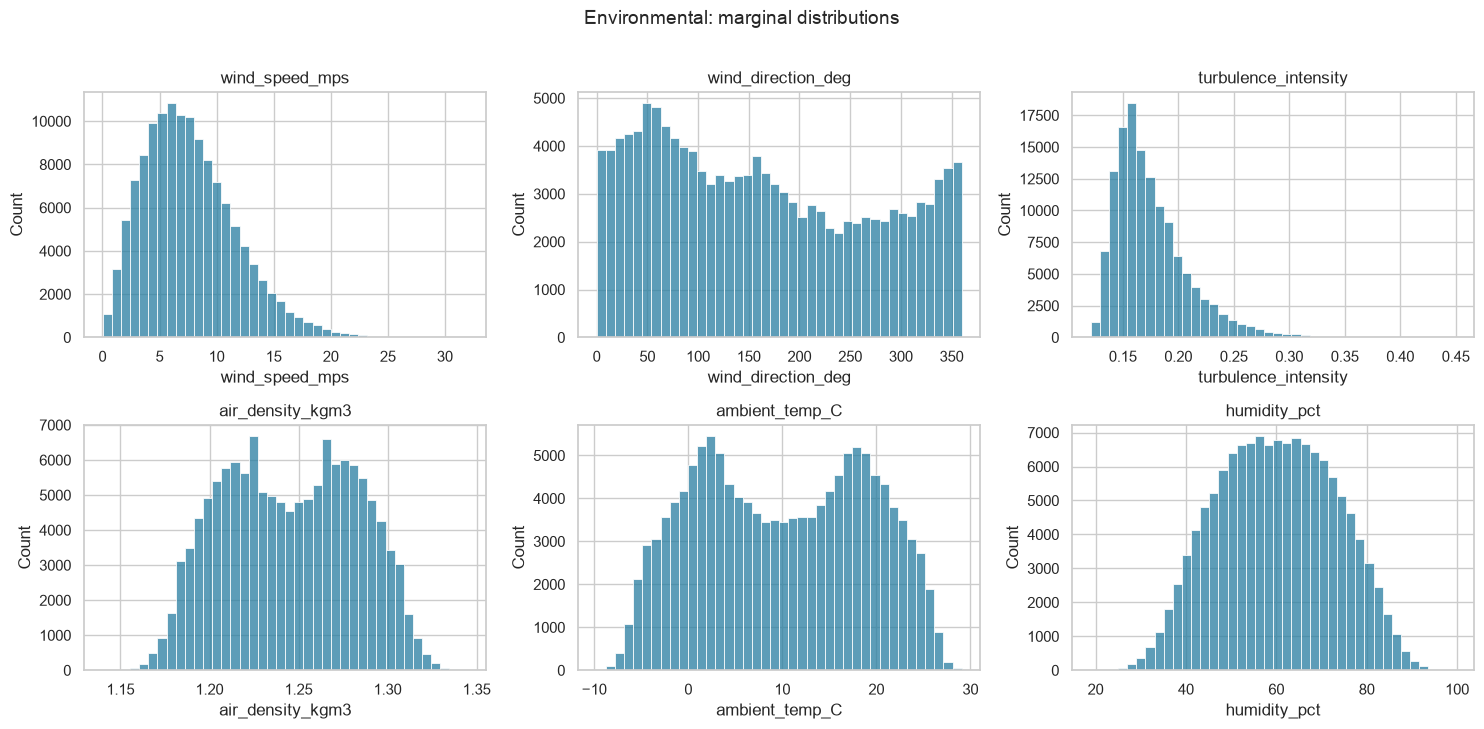

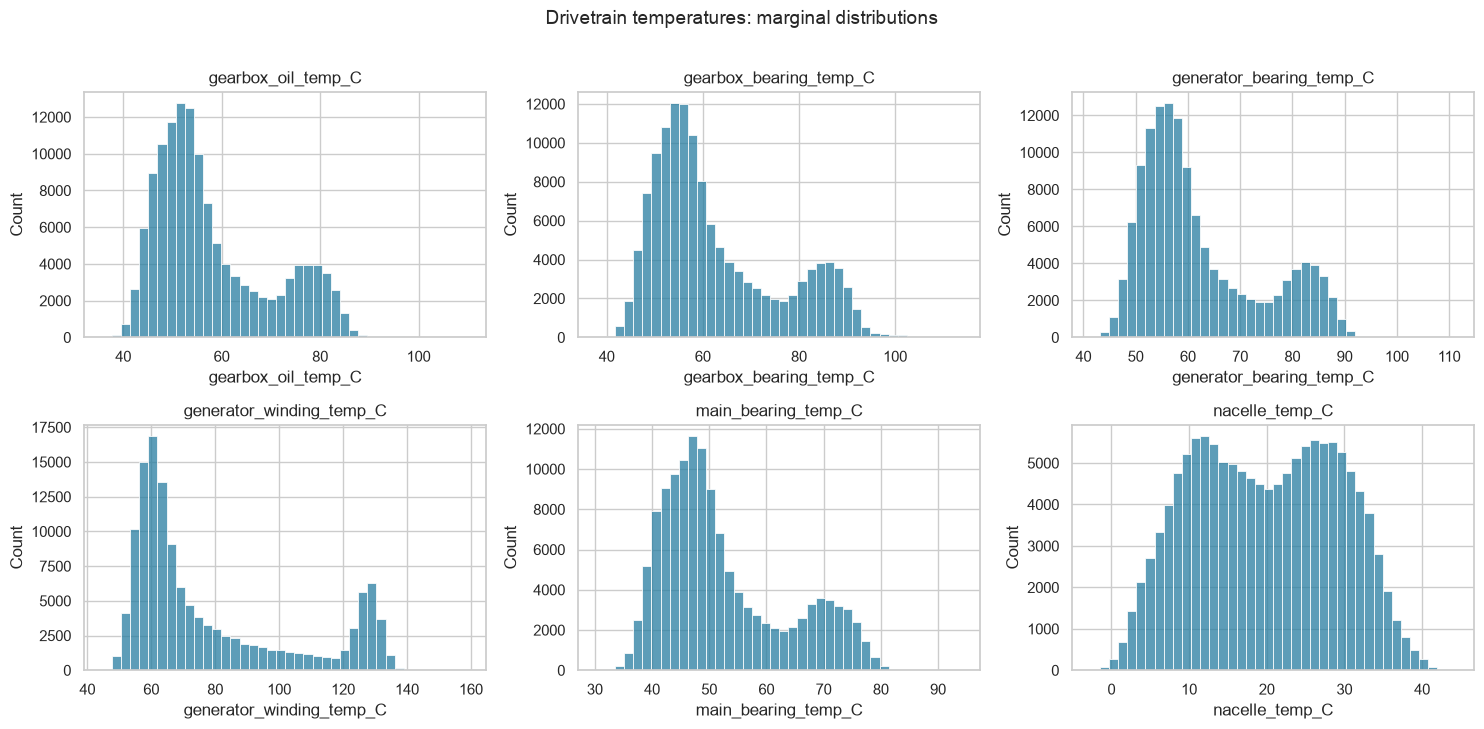

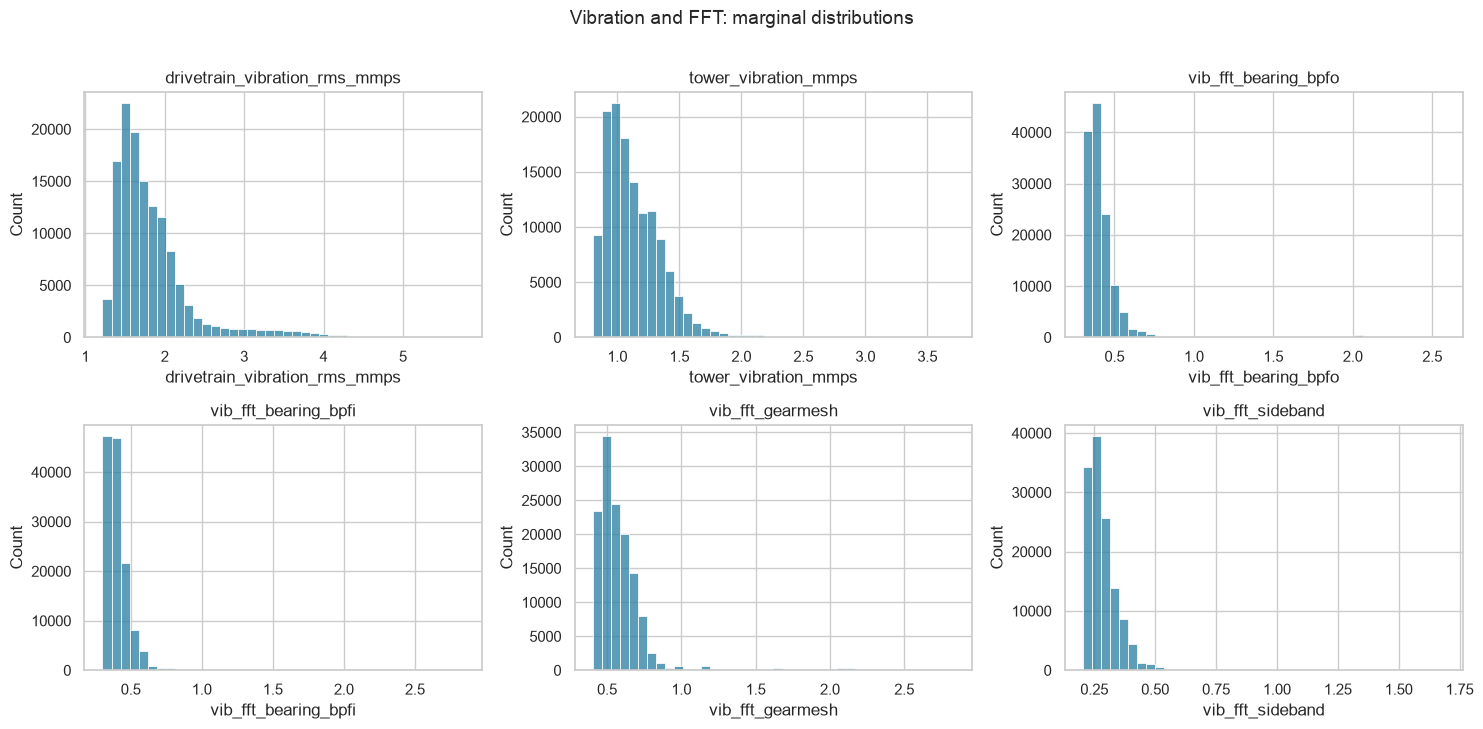

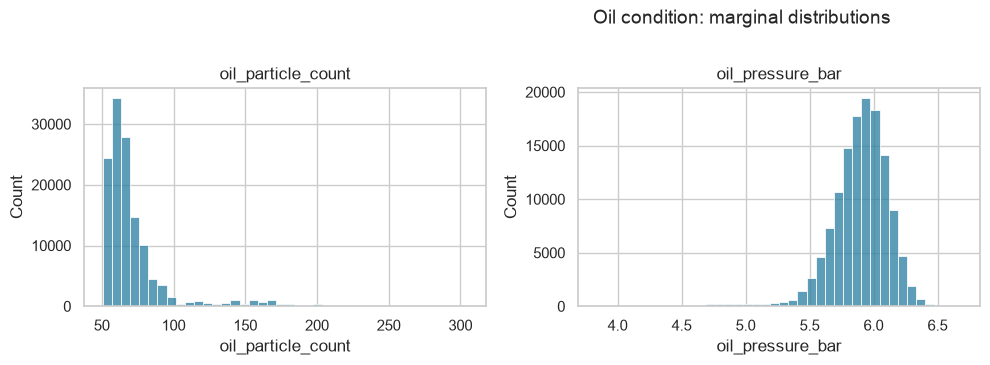

In [16]:
for group_name, columns in sensor_groups.items():
    ncols = 3
    nrows = int(np.ceil(len(columns) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.6 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for axis, column in zip(axes, columns):
        sns.histplot(df[column], bins=40, ax=axis, color="#277da1")
        axis.set_title(column)
    for axis in axes[len(columns):]:
        axis.remove()
    fig.suptitle(f"{group_name}: marginal distributions", fontsize=14, y=1.01)
    fig.tight_layout()
    plt.show()

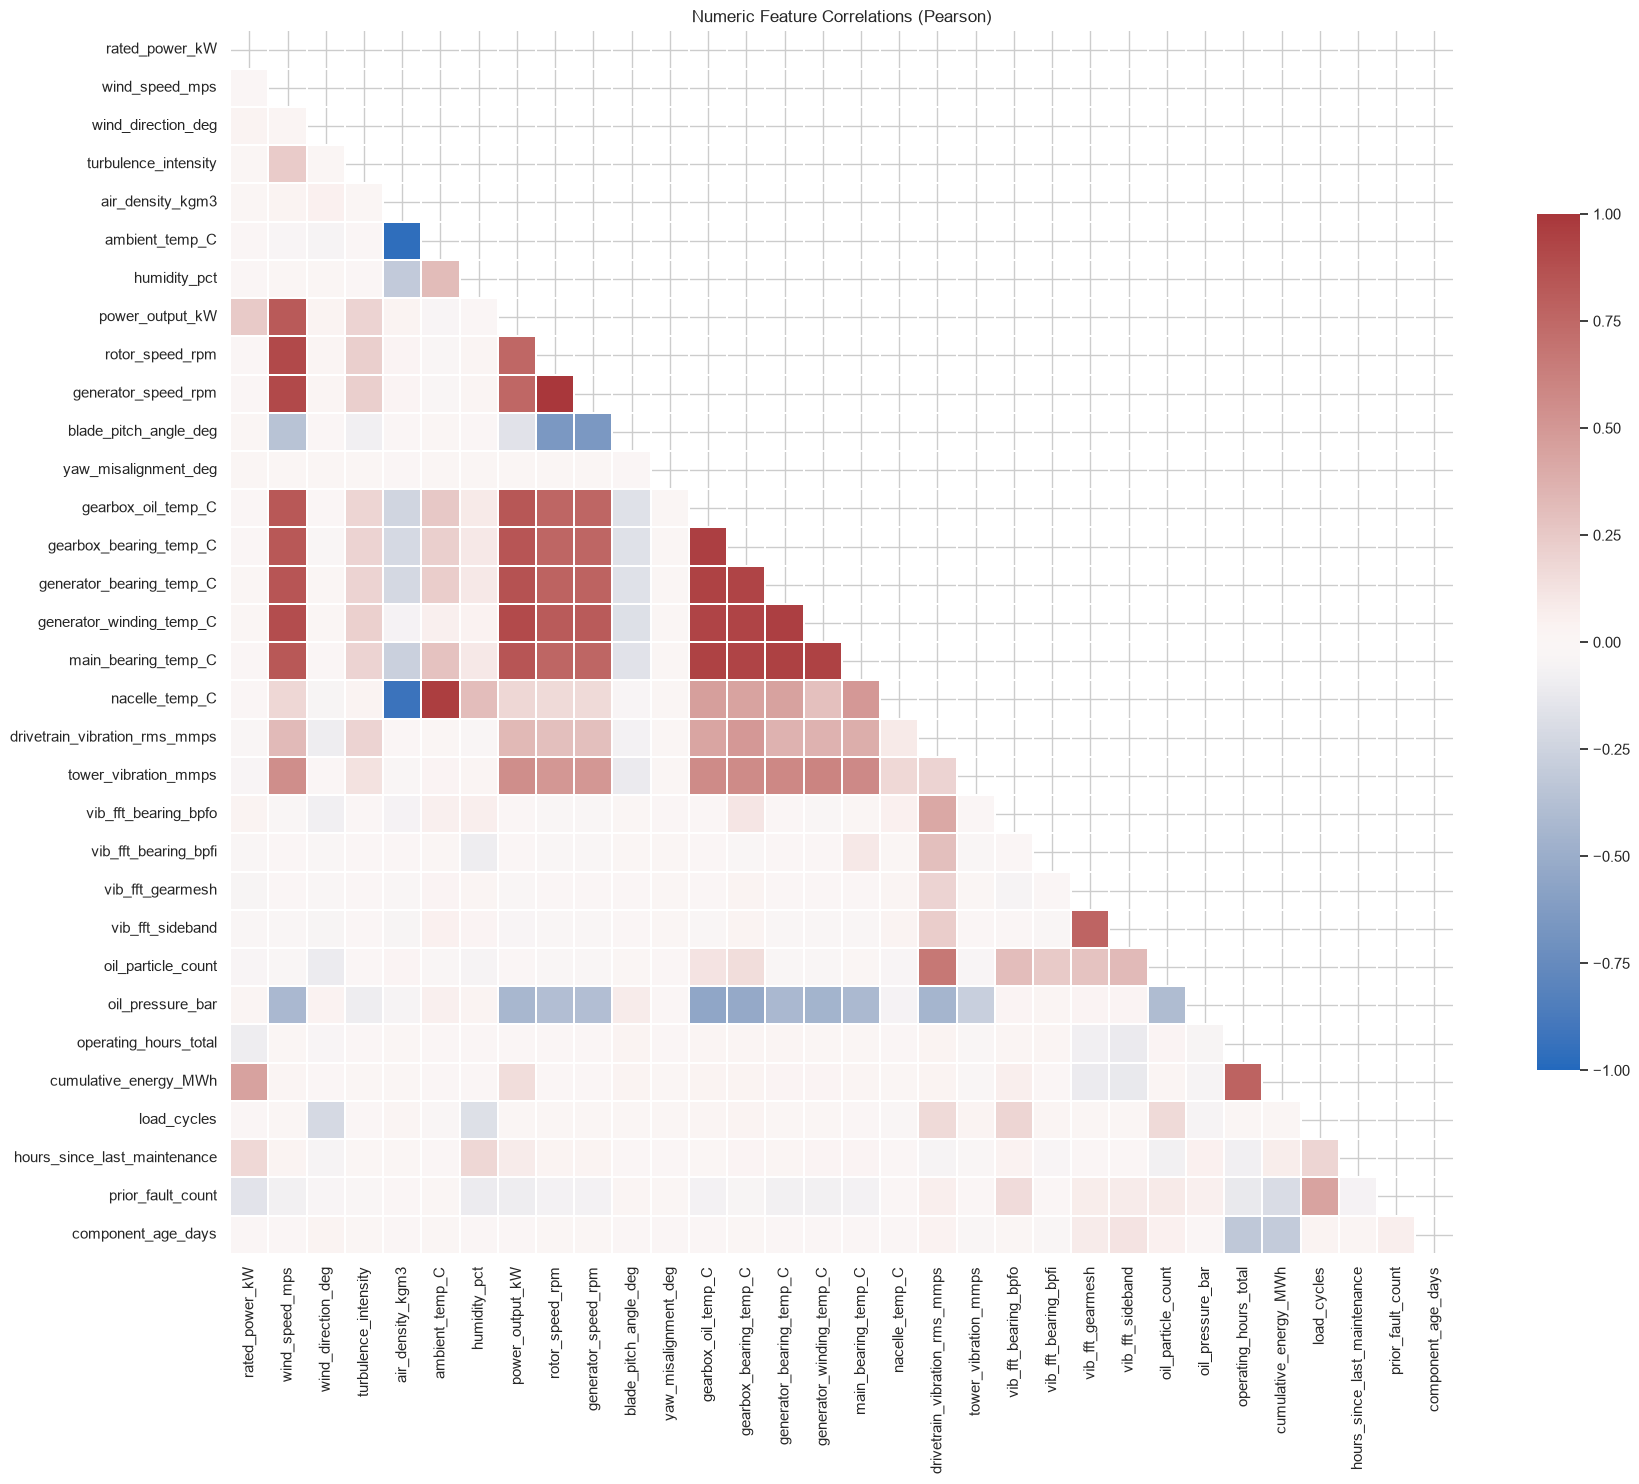

In [17]:
numeric_feature_columns = df.drop(columns=["failure"]).select_dtypes(include="number").columns
correlations = df[numeric_feature_columns].corr()
mask = np.triu(np.ones_like(correlations, dtype=bool))
plt.figure(figsize=(19, 15))
sns.heatmap(correlations, mask=mask, cmap="vlag", center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.25, cbar_kws={"shrink": 0.7}, xticklabels=True, yticklabels=True)
plt.title("Numeric Feature Correlations (Pearson)")
plt.tight_layout()
plt.show()

## Key Findings Recap

- The CSV contains 131,760 rows and 35 columns, occupies 47.78 MiB in memory, and spans 2024-01-01 00:00 through 2024-03-01 23:50 with no timestamp parse failures.
- All 15 turbines contain 8,784 records and have contiguous 10-minute cadence, with no timestamp gaps, duplicate timestamps, or out-of-order transitions.
- Missing values occur only in `generator_bearing_temp_C` (690; 0.524%), `gearbox_oil_temp_C` (645; 0.490%), and `oil_pressure_bar` (636; 0.483%); chi-square checks found no association with turbine or calendar date at alpha 0.05.
- The data has zero duplicate full rows and zero duplicate `timestamp`–`turbine_id` keys; the documented physical-range screens also flagged zero rows.
- Among 14,875 rows below 3 m/s, none exceeded 1 kW, while 3,805 exceeded 0.1 rotor rpm and 4,551 exceeded 10 generator rpm under the stated near-zero tolerances.
- The target contains 127,807 normal rows (97.000%) and 3,953 failure rows (3.000%), meeting the notebook's documented rare-event criterion and supporting recall-first, PR-aware evaluation later.
- The 3,953 failure rows form 219 per-turbine episodes: 69 isolated one-row episodes and 150 multi-row episodes, with a median of 3 rows and a maximum of 227 rows per episode.
- Six maintenance or cumulative-history fields were flagged for later provenance review; future splits must be time-based within turbine and must keep each labeled failure episode within one split.